# Instalando o torchmeta via pip.

In [1]:
!pip3 install torchmeta

!mkdir ./datasets

mkdir: cannot create directory ‘./datasets’: File exists


# Utils.

In [2]:
import torch

from collections import OrderedDict


def get_accuracy(logits, targets):
    """Compute the accuracy (after adaptation) of MAML on the test/query points
    Parameters
    ----------
    logits : `torch.FloatTensor` instance
        Outputs/logits of the model on the query points. This tensor has shape
        `(num_examples, num_classes)`.
    targets : `torch.LongTensor` instance
        A tensor containing the targets of the query points. This tensor has 
        shape `(num_examples,)`.
    Returns
    -------
    accuracy : `torch.FloatTensor` instance
        Mean accuracy on the query points
    """
    _, predictions = torch.max(logits, dim=-1)
    return torch.mean(predictions.eq(targets).float())

# Definindo o modelo.

In [3]:
import torch.nn as nn
from torchmeta.modules import (MetaModule, MetaSequential, MetaConv2d,
                               MetaBatchNorm2d, MetaLinear)


def conv3x3(in_channels, out_channels, **kwargs):
    return MetaSequential(
        MetaConv2d(in_channels, out_channels, kernel_size=3, padding=1, **kwargs),
        MetaBatchNorm2d(out_channels, momentum=1., track_running_stats=False),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

class ConvolutionalNeuralNetwork(MetaModule):

    def __init__(self, in_channels, out_features, hidden_size=64):

        super(ConvolutionalNeuralNetwork, self).__init__()
        
        self.in_channels = in_channels
        self.out_features = out_features
        self.hidden_size = hidden_size

        self.features = MetaSequential(
            conv3x3(in_channels, hidden_size),
            conv3x3(hidden_size, hidden_size),
            conv3x3(hidden_size, hidden_size),
            conv3x3(hidden_size, hidden_size)
        )

        self.classifier = MetaLinear(hidden_size, out_features)

    def forward(self, inputs, params=None):

        features = self.features(inputs, params=self.get_subdict(params, 'features'))
        features = features.view((features.size(0), -1))
        logits = self.classifier(features, params=self.get_subdict(params, 'classifier'))
        
        return logits

# Procedimento de treino.

In [4]:
import os
import torch
import torch.nn.functional as F
from tqdm import tqdm
import logging

from torchmeta.datasets.helpers import omniglot
from torchmeta.utils.data import BatchMetaDataLoader
from torchmeta.utils.gradient_based import gradient_update_parameters

from matplotlib import pyplot as plt

logger = logging.getLogger(__name__)


class Args:

    folder = './datasets/'
    num_shots = 5
    num_ways = 5

    first_order = False
    step_size = 0.4
    hidden_size = 64

    output_folder = None # './outputs/'
    batch_size = 16
    num_batches = 100
    num_workers = 4
    download = True
    use_cuda = True

    device = torch.device('cuda' if use_cuda and torch.cuda.is_available() else 'cpu')

args = Args()




# Definindo datasets.

/usr/local/lib/python3.7/dist-packages/torch/utils/data/dataloader.py:477: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))
/usr/local/lib/python3.7/dist-packages/torchvision/transforms/functional.py:943: UserWarning: Argument interpolation should be of type InterpolationMode instead of int. Please, use InterpolationMode enum.
  "Argument interpolation should be of type InterpolationMode instead of int. "
/usr/local/lib/python3.7/dist-packages/torchvision/transforms/functional.py:943: UserWarning: Argument interpolation should be of type InterpolationMode instead of int. Please, use InterpolationMode enum.
  "Argument interpolation should be of type Interpolat

Train inputs shape: torch.Size([16, 25, 1, 28, 28])
Train targets shape: torch.Size([16, 25])
Test inputs shape: torch.Size([16, 5, 1, 28, 28])
Test targets shape: torch.Size([16, 5])


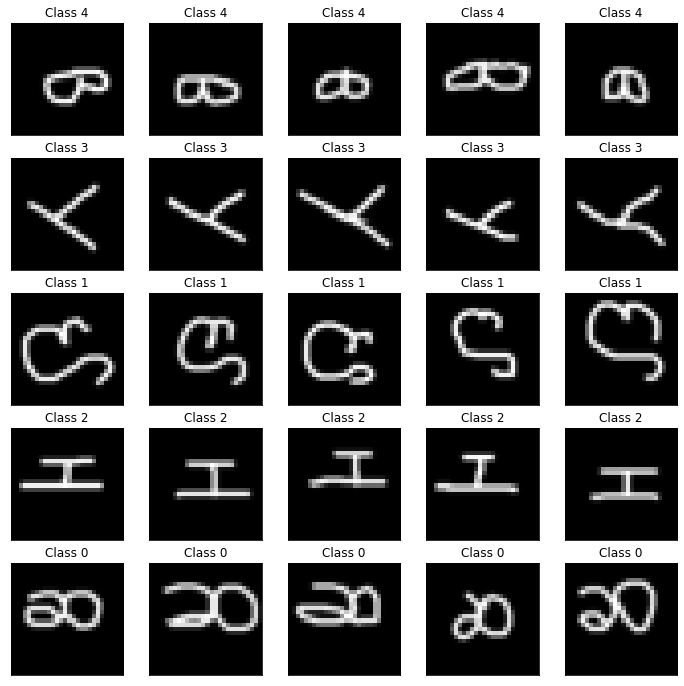

Train inputs shape: torch.Size([16, 25, 1, 28, 28])
Train targets shape: torch.Size([16, 25])
Test inputs shape: torch.Size([16, 5, 1, 28, 28])
Test targets shape: torch.Size([16, 5])


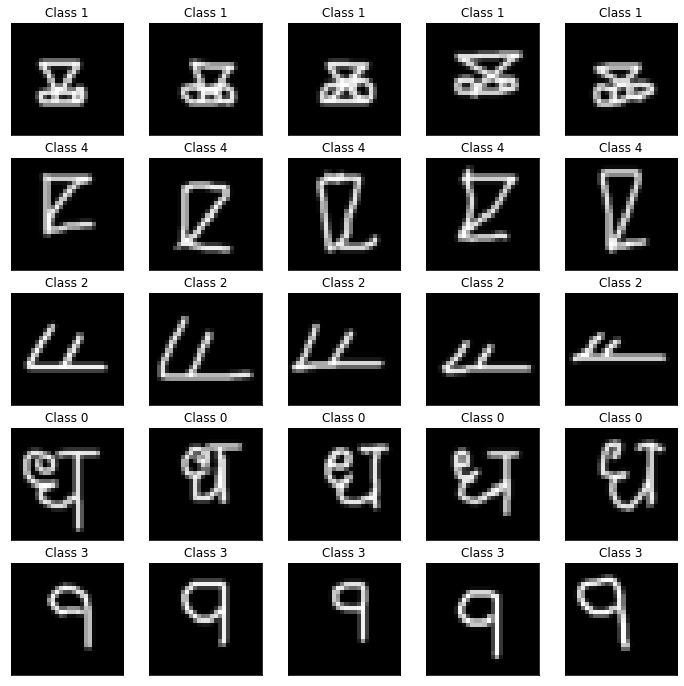

Train inputs shape: torch.Size([16, 25, 1, 28, 28])
Train targets shape: torch.Size([16, 25])
Test inputs shape: torch.Size([16, 5, 1, 28, 28])
Test targets shape: torch.Size([16, 5])


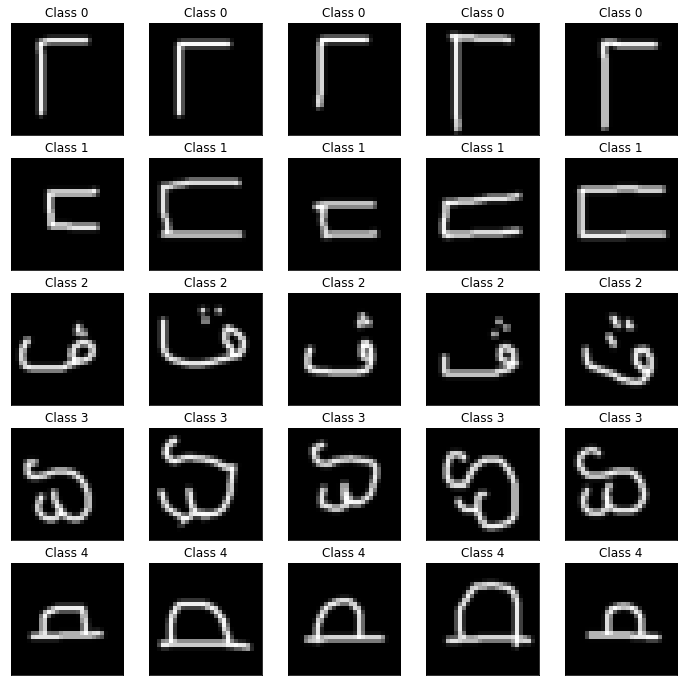

Train inputs shape: torch.Size([16, 25, 1, 28, 28])
Train targets shape: torch.Size([16, 25])
Test inputs shape: torch.Size([16, 5, 1, 28, 28])
Test targets shape: torch.Size([16, 5])


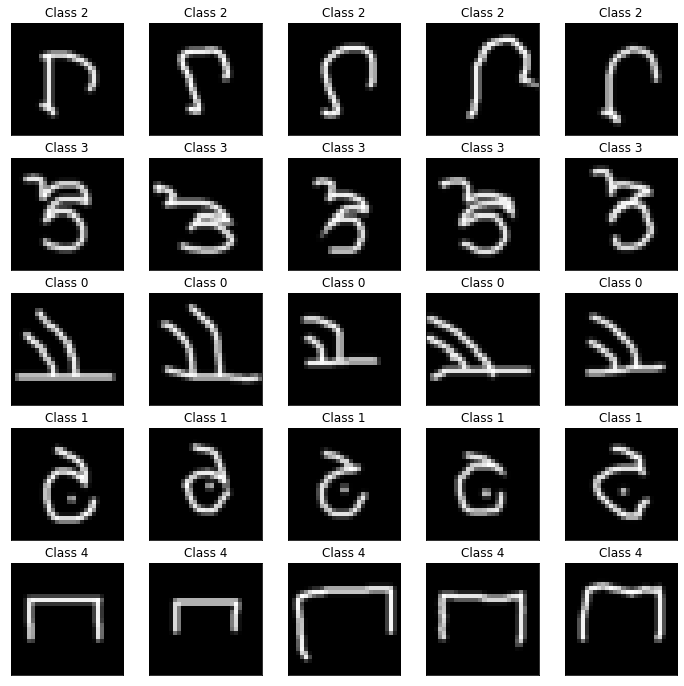

Train inputs shape: torch.Size([16, 25, 1, 28, 28])
Train targets shape: torch.Size([16, 25])
Test inputs shape: torch.Size([16, 5, 1, 28, 28])
Test targets shape: torch.Size([16, 5])


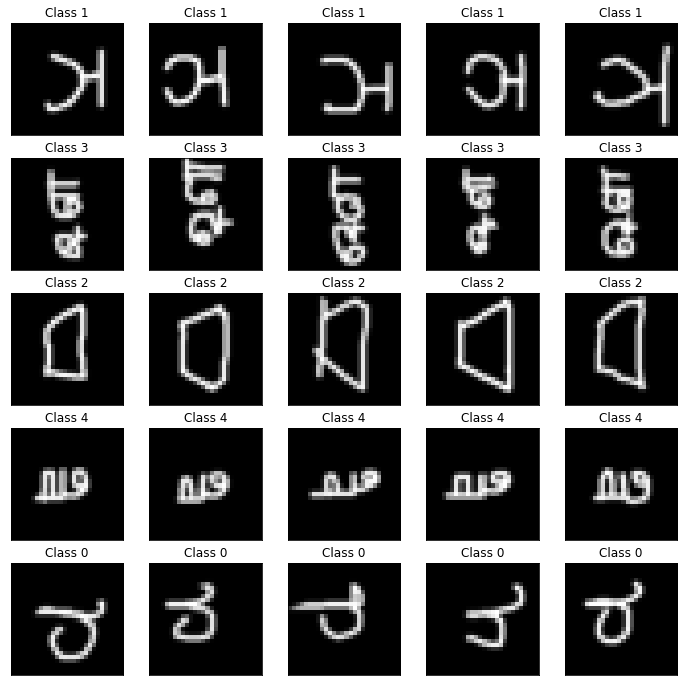

In [5]:
%matplotlib inline

dataset = omniglot(args.folder,
                    shots=args.num_shots,
                    ways=args.num_ways,
                    shuffle=True,
                    test_shots=1, # 1 único sample de cada classe para teste.
                    meta_train=True,
                    download=args.download)
dataloader = BatchMetaDataLoader(dataset,
                                    batch_size=args.batch_size,
                                    shuffle=True,
                                    num_workers=args.num_workers)
    
for i, batch in enumerate(dataloader):

    if i >= 5:
        break

    train_inputs, train_targets = batch['train']
    print('Train inputs shape: {0}'.format(train_inputs.shape))    # (16, 25, 1, 28, 28)
    print('Train targets shape: {0}'.format(train_targets.shape))  # (16, 25)

    test_inputs, test_targets = batch['test']
    print('Test inputs shape: {0}'.format(test_inputs.shape))      # (16, 75, 1, 28, 28)
    print('Test targets shape: {0}'.format(test_targets.shape))    # (16, 75)

    fig, ax = plt.subplots(5, 5, figsize=(12, 12))

    for s in range(args.num_shots):
        for w in range(args.num_ways):
            img = train_inputs[0, (s * 5) + w].squeeze().numpy()
            lab = train_targets[0, (s * 5) + w].item()
            ax[s, w].imshow(img, cmap='gray')
            ax[s, w].set_title('Class %d' % (lab))
            ax[s, w].set_yticks([])
            ax[s, w].set_xticks([])

    plt.show()

# Definindo modelo e otimizador.

In [6]:
model = ConvolutionalNeuralNetwork(1,
                                    args.num_ways,
                                    hidden_size=args.hidden_size)
model.to(device=args.device)
model.train()
meta_optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Procedimento de meta-treino.

In [7]:
# Training loop.
with tqdm(dataloader, total=args.num_batches) as pbar:
    for batch_idx, batch in enumerate(pbar):
        model.zero_grad()

        train_inputs, train_targets = batch['train']
        train_inputs = train_inputs.to(device=args.device)
        train_targets = train_targets.to(device=args.device)

        test_inputs, test_targets = batch['test']
        test_inputs = test_inputs.to(device=args.device)
        test_targets = test_targets.to(device=args.device)

        outer_loss = torch.tensor(0., device=args.device)
        accuracy = torch.tensor(0., device=args.device)
        for task_idx, (train_input, train_target, test_input,
                test_target) in enumerate(zip(train_inputs, train_targets,
                test_inputs, test_targets)):
            train_logit = model(train_input)
            inner_loss = F.cross_entropy(train_logit, train_target)

            model.zero_grad()
            params = gradient_update_parameters(model,
                                                inner_loss,
                                                step_size=args.step_size,
                                                first_order=args.first_order)

            test_logit = model(test_input, params=params)
            outer_loss += F.cross_entropy(test_logit, test_target)

            with torch.no_grad():
                accuracy += get_accuracy(test_logit, test_target)

        outer_loss.div_(args.batch_size)
        accuracy.div_(args.batch_size)

        outer_loss.backward()
        meta_optimizer.step()

        pbar.set_postfix(accuracy='{0:.4f}'.format(accuracy.item()))
        if batch_idx >= args.num_batches:
            break

  0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.7/dist-packages/torch/utils/data/dataloader.py:477: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))
/usr/local/lib/python3.7/dist-packages/torchvision/transforms/functional.py:943: UserWarning: Argument interpolation should be of type InterpolationMode instead of int. Please, use InterpolationMode enum.
  "Argument interpolation should be of type InterpolationMode instead of int. "
/usr/local/lib/python3.7/dist-packages/torchvision/transforms/functional.py:943: UserWarning: Argument interpolation should be of type InterpolationMode instead of int. Please, use InterpolationMode enum.
  "Argument int